# Расчётно-графическая работа №2
Выполнили Воробьёв Андрей (465440), Шакина Анна (396675)

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f

# Задача 1 (вариант 5)

Пусть $X_1, \ldots, X_n$ – i.i.d. величины из некоторого распределения, которое параметризируется параметром $\theta \in E$.
Пусть $\overline{X}_n = (X_1 + \ldots + X_n)/n$, а $\mu_\theta$ – математическое ожидание случайной величины $X_i$.

Найти с помощью неравенства Чебышёва и центральной предельной теоремы номер $n_{\delta,\varepsilon}$, при котором для любого $\theta \in E$ и заданных $\delta, \varepsilon \in (0,1)$ выполняется соотношение
$$
P\bigl(|\overline{X}_{n_{\delta,\varepsilon}} - \mu_\theta| \le \varepsilon\bigr) \ge 1 - \delta.
$$

Сгенерировать 100 выборок найденного с помощью неравенства Чебышёва объёма $n_{\delta,\varepsilon}$ и посчитать количество и долю выборок, для которых
$$
|\overline{X}_{n_{\delta,\varepsilon}} - \mu_\theta| \le \varepsilon.
$$

Параметры эксперимента: $\varepsilon = 0.01$, $\delta = 0.05$ и $\theta$, при котором найдено $n_{\delta,\varepsilon}$.
То же самое сделать и для $n_{\delta,\varepsilon}$, найденного с помощью ЦПТ.

Вариант 5: распределение $\mathrm{Exp}(\lambda)$, $\lambda \in [1,5]$.


## Аналитическая часть

### 1. Распределение и его моменты

Пусть $X_1, \ldots, X_n$ — i.i.d. случайные величины из распределения, параметризуемого параметром $\theta \in E$.

Обозначим:
$$
\overline X_n = \frac{1}{n}\sum_{i=1}^n X_i, \qquad
\mu_\theta = \mathbb{E}_\theta X_i, \qquad
\sigma_\theta^2 = \operatorname{Var}_\theta(X_i).
$$

Матожидание выборочного среднего.

По линейности матожидания:
$$
\mathbb{E}_\theta \overline X_n
=
\mathbb{E}_\theta\left(\frac{1}{n}\sum_{i=1}^n X_i\right)
=
\frac{1}{n}\sum_{i=1}^n \mathbb{E}_\theta X_i.
$$
Все $X_i$ одинаково распределены, значит $\mathbb{E}_\theta X_i = \mu_\theta$ для любого $i$, поэтому
$$
\mathbb{E}_\theta \overline X_n
=
\frac{1}{n}\sum_{i=1}^n \mu_\theta
=
\frac{1}{n}\cdot n\cdot \mu_\theta
=
\mu_\theta.
$$

Дисперсия выборочного среднего.

Используем независимость $X_i$ и формулу для дисперсии суммы:
$$
\operatorname{Var}_\theta(\overline X_n)
=
\operatorname{Var}_\theta\left(\frac{1}{n}\sum_{i=1}^n X_i\right)
=
\frac{1}{n^2}\operatorname{Var}_\theta\left(\sum_{i=1}^n X_i\right)
=
\frac{1}{n^2}\sum_{i=1}^n \operatorname{Var}_\theta(X_i)
$$ Поскольку все $X_i$ имеют одну и ту же дисперсию $\sigma_\theta^2$:
$$
\operatorname{Var}_\theta(\overline X_n)
=
\frac{1}{n^2}\sum_{i=1}^n \sigma_\theta^2
=
\frac{1}{n^2}\cdot n\cdot \sigma_\theta^2
=
\frac{\sigma_\theta^2}{n}.
$$

То есть:
$$
\mathbb{E}_\theta \overline X_n = \mu_\theta, \qquad
\operatorname{Var}_\theta(\overline X_n) = \frac{\sigma_\theta^2}{n}.
$$

Теперь подставляем конкретное распределение.

В условии:
$$
X_i \sim \mathrm{Exp}(\lambda), \qquad \theta = \lambda,\qquad E = [1,5].
$$

Для экспоненциального распределения с параметром $\lambda$:
$$
\mu_\theta = \mu_\lambda = \mathbb E_\lambda X_i = \frac{1}{\lambda}, \qquad
\sigma_\theta^2 = \sigma_\lambda^2 = \operatorname{Var}_\lambda(X_i) = \frac{1}{\lambda^2}.
$$

Тогда дисперсия выборочного среднего:
$$
\operatorname{Var}_\lambda(\overline X_n)
=
\frac{\sigma_\lambda^2}{n}
=
\frac{1/\lambda^2}{n}
=
\frac{1}{\lambda^2 n}.
$$

### 2. $n_{\delta,\varepsilon}$ по неравенству Чебышёва

Неравенство Чебышёва для $\overline X_n$ в наших обозначениях:
$$
\mathbb P_\theta\bigl(|\overline X_n - \mu_\theta| \ge \varepsilon\bigr)
\le
\frac{\operatorname{Var}_\theta(\overline X_n)}{\varepsilon^2}
=
\frac{\sigma_\theta^2}{n\varepsilon^2}.
$$

Нам нужно, чтобы для некоторого $n_{\delta,\varepsilon}$ выполнялось
$$
\mathbb P_\theta\bigl(|\overline X_{n_{\delta,\varepsilon}} - \mu_\theta| \le \varepsilon\bigr) \ge 1 - \delta
\quad \text{для всех } \theta \in E.
$$

Заметим, что
$$
\mathbb P_\theta\bigl(|\overline X_{n_{\delta,\varepsilon}} - \mu_\theta| \le \varepsilon\bigr)
=
1 - \mathbb P_\theta\bigl(|\overline X_{n_{\delta,\varepsilon}} - \mu_\theta| \ge \varepsilon\bigr).
$$

По неравенству Чебышёва:
$$
\mathbb P_\theta\bigl(|\overline X_{n_{\delta,\varepsilon}} - \mu_\theta| \ge \varepsilon\bigr)
\le
\frac{\sigma_\theta^2}{n_{\delta,\varepsilon}\varepsilon^2}.
$$

Чтобы
$$
\mathbb P_\theta\bigl(|\overline X_{n_{\delta,\varepsilon}} - \mu_\theta| \le \varepsilon\bigr) \ge 1 - \delta,
$$
достаточно потребовать
$$
\frac{\sigma_\theta^2}{n_{\delta,\varepsilon}\varepsilon^2} \le \delta
\quad \text{для всех } \theta\in E,
$$
то есть
$$
\sup_{\theta\in E} \frac{\sigma_\theta^2}{n_{\delta,\varepsilon}\varepsilon^2} \le \delta.
$$

По условию
$$
\sigma_\theta^2 = \frac{1}{\lambda^2}, \qquad \lambda \in [1,5],
$$
поэтому
$$
\sup_{\theta\in E} \sigma_\theta^2 = \sup_{\lambda\in[1,5]} \frac{1}{\lambda^2}.
$$

Функция $1/\lambda^2$ убывает по $\lambda>0$, значит максимум на отрезке $[1,5]$ достигается при наименьшем значении $\lambda$, то есть при $\lambda=1$:
$$
\sup_{\lambda\in[1,5]} \frac{1}{\lambda^2} = \frac{1}{1^2} = 1.
$$

Подставляем в условие:
$$
\sup_{\theta\in E} \frac{\sigma_\theta^2}{n_{\delta,\varepsilon}\varepsilon^2}
=
\frac{1}{n_{\delta,\varepsilon}\varepsilon^2}
\le \delta.
$$

Отсюда получаем неравенство:
$$
\frac{1}{n_{\delta,\varepsilon}\varepsilon^2} \le \delta
\quad \Longrightarrow \quad
n_{\delta,\varepsilon}\varepsilon^2 \ge \frac{1}{\delta}
\quad \Longrightarrow \quad
n_{\delta,\varepsilon} \ge \frac{1}{\delta\varepsilon^2}.
$$

Минимальное целое $n_{\delta,\varepsilon}$, удовлетворяющее этому условию,
берём как
$$
n_{\delta,\varepsilon}^{\text{Чеб}}
=
\left\lceil \frac{1}{\delta \varepsilon^2} \right\rceil.
$$

Теперь подставляем конкретные значения параметров эксперимента:
$$
\varepsilon = 0.01,\qquad \delta = 0.05.
$$

Сначала считаем $\varepsilon^2$:
$$
\varepsilon^2 = (0.01)^2 = 0.0001 = 10^{-4}.
$$

Дальше считаем произведение:
$$
\delta \varepsilon^2 = 0.05 \cdot 0.0001.
$$
$$
\delta \varepsilon^2 = (5\cdot 10^{-2})\cdot(10^{-4}) = 5\cdot 10^{-6}.
$$

Теперь
$$
\frac{1}{\delta \varepsilon^2} = \frac{1}{5\cdot 10^{-6}}.
$$
Заметим, что
$$
\mathbb P_\theta\bigl(|\overline X_{n_{\delta,\varepsilon}} - \mu_\theta| \le \varepsilon\bigr)
=
1 - \mathbb P_\theta\bigl(|\overline X_{n_{\delta,\varepsilon}} - \mu_\theta| \ge \varepsilon\bigr).
$$

По неравенству Чебышёва:
$$
\mathbb P_\theta\bigl(|\overline X_{n_{\delta,\varepsilon}} - \mu_\theta| \ge \varepsilon\bigr)
\le
\frac{\sigma_\theta^2}{n_{\delta,\varepsilon}\varepsilon^2}.
$$

Чтобы
$$
\mathbb P_\theta\bigl(|\overline X_{n_{\delta,\varepsilon}} - \mu_\theta| \le \varepsilon\bigr) \ge 1 - \delta,
$$
достаточно потребовать
$$
\frac{\sigma_\theta^2}{n_{\delta,\varepsilon}\varepsilon^2} \le \delta
\quad \text{для всех } \theta\in E,
$$
то есть
$$
\sup_{\theta\in E} \frac{\sigma_\theta^2}{n_{\delta,\varepsilon}\varepsilon^2} \le \delta.
$$
$$
\sigma_\theta^2 = \frac{1}{\lambda^2}, \qquad \lambda \in [1,5],
$$
поэтому
$$
\sup_{\theta\in E} \sigma_\theta^2 = \sup_{\lambda\in[1,5]} \frac{1}{\lambda^2}.
$$

Функция $1/\lambda^2$ убывает по $\lambda>0$, значит максимум на отрезке $[1,5]$ достигается при наименьшем значении $\lambda$, то есть при $\lambda=1$:
$$
\sup_{\lambda\in[1,5]} \frac{1}{\lambda^2} = \frac{1}{1^2} = 1.
$$

Подставляем в условие:
$$
\sup_{\theta\in E} \frac{\sigma_\theta^2}{n_{\delta,\varepsilon}\varepsilon^2}
=
\frac{1}{n_{\delta,\varepsilon}\varepsilon^2}
\le \delta.
$$

Отсюда получаем простое неравенство:
$$
\frac{1}{n_{\delta,\varepsilon}\varepsilon^2} \le \delta
\quad \Longrightarrow \quad
n_{\delta,\varepsilon}\varepsilon^2 \ge \frac{1}{\delta}
\quad \Longrightarrow \quad
n_{\delta,\varepsilon} \ge \frac{1}{\delta\varepsilon^2}.
$$

Минимальное целое $n_{\delta,\varepsilon}$, удовлетворяющее этому условию,
берём как
$$
n_{\delta,\varepsilon}^{\text{Чеб}}
=
\left\lceil \frac{1}{\delta \varepsilon^2} \right\rceil.
$$

Теперь подставляем конкретные значения параметров эксперимента:
$$
\varepsilon = 0.01,\qquad \delta = 0.05.
$$

Сначала считаем $\varepsilon^2$:
$$
\varepsilon^2 = (0.01)^2 = 0.0001 = 10^{-4}.
$$

Дальше считаем произведение:
$$
\delta \varepsilon^2 = 0.05 \cdot 0.0001
$$
$$
\delta \varepsilon^2 = (5\cdot 10^{-2})\cdot(10^{-4}) = 5\cdot 10^{-6}.
$$

Теперь
$$
\frac{1}{\delta \varepsilon^2} = \frac{1}{5\cdot 10^{-6}}.
$$
Заметим, что
$$
\frac{1}{5\cdot 10^{-6}} = \frac{1}{5}\cdot 10^{6} = 0.2\cdot 10^{6} = 200000.
$$

Итак,
$$
n_{\delta,\varepsilon}^{\text{Чеб}} = \left\lceil 200000 \right\rceil = 200000.
$$

### 3. $n_{\delta,\varepsilon}$ по ЦПТ

Центральная предельная теорема для выборочного среднего говорит, что
$$
\sqrt{n}\,\frac{\overline X_n - \mu_\theta}{\sigma_\theta}
\overset{d}\longrightarrow N(0,1),
$$
то есть при больших $n$ случайная величина
$$
\sqrt{n}\,\frac{\overline X_n - \mu_\theta}{\sigma_\theta}
$$
по распределению близка к стандартной нормальной $Z\sim N(0,1)$.

Отсюда примерно:
$$
\mathbb P_\theta\bigl(|\overline X_n - \mu_\theta| \le \varepsilon\bigr)
\approx
\mathbb P\Bigl(|Z| \le \frac{\varepsilon \sqrt{n}}{\sigma_\theta}\Bigr),
$$
так как
$$
|\overline X_n - \mu_\theta| \le \varepsilon
\quad \Longleftrightarrow \quad
\left|\sqrt{n}\,\frac{\overline X_n - \mu_\theta}{\sigma_\theta}\right|
\le
\frac{\varepsilon \sqrt{n}}{\sigma_\theta}.
$$

Для $Z\sim N(0,1)$
$$
\mathbb P\bigl(|Z|\le a\bigr) = \mathbb P(-a \le Z \le a) = \Phi(a) - \Phi(-a).
$$
А так как нормальное распределение симметрично и $\Phi(-a)=1-\Phi(a)$, то
$$
\mathbb P(-a \le Z \le a) = \Phi(a) - (1-\Phi(a)) = 2\Phi(a)-1.
$$

Применяем это к $a = \dfrac{\varepsilon\sqrt{n}}{\sigma_\theta}$:
$$
\mathbb P\Bigl(|Z| \le \frac{\varepsilon \sqrt{n}}{\sigma_\theta}\Bigr)
=
2\Phi\Bigl(\frac{\varepsilon \sqrt{n}}{\sigma_\theta}\Bigr) - 1.
$$

Значит,
$$
\mathbb P_\theta\bigl(|\overline X_n - \mu_\theta| \le \varepsilon\bigr)
\approx
2\Phi\Bigl(\frac{\varepsilon \sqrt{n}}{\sigma_\theta}\Bigr) - 1.
$$

Хотим, чтобы для $n_{\delta,\varepsilon}$ выполнялось
$$
\mathbb P_\theta\bigl(|\overline X_{n_{\delta,\varepsilon}} - \mu_\theta| \le \varepsilon\bigr)
\gtrsim 1 - \delta.
$$
Приближённо это условие запишем как
$$
2\Phi\Bigl(\frac{\varepsilon \sqrt{n_{\delta,\varepsilon}}}{\sigma_\theta}\Bigr) - 1
\ge 1 - \delta.
$$
$$
2\Phi\Bigl(\frac{\varepsilon \sqrt{n_{\delta,\varepsilon}}}{\sigma_\theta}\Bigr)
\ge 2 - \delta.
$$
Делим обе части на 2:
$$
\Phi\Bigl(\frac{\varepsilon \sqrt{n_{\delta,\varepsilon}}}{\sigma_\theta}\Bigr)
\ge 1 - \frac{\delta}{2}.
$$

Обозначим квантиль стандартного нормального распределения через $z_{1-\delta/2}$:
$$
\Phi(z_{1-\delta/2}) = 1 - \frac{\delta}{2}.
$$

Тогда, чтобы неравенство выполнялось, достаточно потребовать
$$
\frac{\varepsilon \sqrt{n_{\delta,\varepsilon}}}{\sigma_\theta} \ge z_{1-\delta/2}.
$$

Решаем это неравенство относительно $n_{\delta,\varepsilon}$.

Сначала умножаем обе части на $\sigma_\theta>0$:
$$
\varepsilon \sqrt{n_{\delta,\varepsilon}} \ge \sigma_\theta z_{1-\delta/2}.
$$
Делим на $\varepsilon>0$:
$$
\sqrt{n_{\delta,\varepsilon}} \ge \frac{\sigma_\theta}{\varepsilon}\,z_{1-\delta/2}.
$$
Возводим обе части в квадрат:
$$
n_{\delta,\varepsilon} \ge
\frac{\sigma_\theta^2}{\varepsilon^2}\,z_{1-\delta/2}^2.
$$
Чтобы это выполнялось для всех $\theta\in E$, берём максимум по $\theta$:
$$
n_{\delta,\varepsilon}^{\text{ЦПТ}}
\approx
\left\lceil
\frac{\sup_{\theta\in E}\sigma_\theta^2}{\varepsilon^2}\,z_{1-\delta/2}^2
\right\rceil.
$$

В нашем случае
$$
\sigma_\theta^2 = \frac{1}{\lambda^2}, \quad \lambda\in[1,5],\quad
\sup_{\lambda\in[1,5]}\frac{1}{\lambda^2}=1,
$$
поэтому
$$
\sup_{\theta\in E}\sigma_\theta^2 = 1.
$$

При $\delta = 0.05$ имеем
$$
1-\frac{\delta}{2} = 1 - \frac{0.05}{2} = 1 - 0.025 = 0.975,
$$
и табличное значение
$$
z_{1-\delta/2} = z_{0.975} \approx 1.96.
$$

Теперь подставляем числа:
$$
\varepsilon = 0.01 \quad \Rightarrow \quad \varepsilon^2 = (0.01)^2 = 0.0001 = 10^{-4}.
$$

Тогда
$$
\frac{1}{\varepsilon^2} = \frac{1}{10^{-4}} = 10^{4} = 10000.
$$

Дальше
$$
z_{1-\delta/2}^2 \approx 1.96^2 = 3.8416.
$$

Итак,
$$
n_{\delta,\varepsilon}^{\text{ЦПТ}}
\approx
\left\lceil
\frac{1}{\varepsilon^2}\cdot z_{1-\delta/2}^2
\right\rceil
=
\left\lceil
10000 \cdot 3.8416
\right\rceil
=
\left\lceil 38416 \right\rceil
=
38416.
$$

Итак, по ЦПТ получаем приближённую оценку
$$
n_{\delta,\varepsilon}^{\text{ЦПТ}} \approx 38416.
$$

## Экспериментальная часть

In [13]:
eps = 0.01
delta = 0.05
lam = 1.0

n_cheb = 200000
z = 1.96
n_clt = int(np.ceil((z / (eps * lam)) ** 2))

def run_experiment(n, lam, eps, m=100):
    mu = 1 / lam
    samples = np.random.exponential(1 / lam, size=(m, n))
    means = samples.mean(axis=1)
    inside = np.abs(means - mu) <= eps
    count = inside.sum()
    freq = count / m
    return count, freq

count_cheb, freq_cheb = run_experiment(n_cheb, lam, eps)
count_clt, freq_clt = run_experiment(n_clt, lam, eps)

print("Чебышёв n:", n_cheb, "количество:", count_cheb, "доля:", freq_cheb)
print("ЦПТ n:", n_clt, "количество:", count_clt, "доля:", freq_clt)


Чебышёв n: 200000 количество: 100 доля: 1.0
ЦПТ n: 38416 количество: 95 доля: 0.95


# Задача 2 (вариант 5)

Требуется с помощью метода моментов найти оценку параметра $\theta$ распределения с плотностью
$$
f_\theta(x) = \frac{1}{(k-1)!\,\theta^k} x^{k-1} e^{-x/\theta}\,\mathbf{1}(x>0),
$$
где $k \in \mathbb{N}$ — известный параметр.

Нужно выписать оценку, её смещение, дисперсию, среднеквадратичную ошибку и указать свойства оценки (с математическим обоснованием).

Далее необходимо провести эксперимент при значениях параметров
$$
\theta = 2,\qquad k = 3.
$$

Схема эксперимента:

1. Задать массив объёмов выборки.
2. Для каждого объёма выборки $n$ сгенерировать $m$ выборок из указанного распределения и для каждой выборки вычислить оценку параметра по найденной формуле.
3. Обработать результаты: вычислить выборочные характеристики разности между оценкой и истинным параметром для каждого $n$, а также количество выборок, для которых ошибка превышает выбранный порог. Визуализировать результаты.


## Аналитическая часть

Рассматривается семейство распределений с плотностью
$$
f_\theta(x)
=
\frac{1}{(k-1)!\,\theta^k}\,x^{k-1} e^{-x/\theta}\,\mathbf{1}(x>0),
\qquad
k\in\mathbb{N}\ \text{известно},\ \theta>0\ \text{неизвестно}.
$$

Пусть $X_1,\ldots,X_n$ — независимые одинаково распределённые случайные величины с этой плотностью.

### 1. Моменты распределения

Из теории гамма-распределения с параметрами $k$ (форма) и $\theta$ (масштаб) известно, что
$$
\mathbb{E} X_1 = k\theta,\qquad
\operatorname{Var}(X_1) = k\theta^2.
$$

Введём выборочное среднее:
$$
\overline X_n = \frac{1}{n}\sum_{i=1}^n X_i.
$$

Посчитаем его матожидание. Используем линейность:
$$
\mathbb{E}\,\overline X_n
=
\mathbb{E}\left(\frac{1}{n}\sum_{i=1}^n X_i\right)
=
\frac{1}{n}\sum_{i=1}^n \mathbb{E}X_i.
$$
Так как все $X_i$ одинаково распределены, $\mathbb{E}X_i = \mathbb{E}X_1 = k\theta$, поэтому
$$
\mathbb{E}\,\overline X_n
=
\frac{1}{n}\sum_{i=1}^n k\theta
=
\frac{1}{n}\cdot n\cdot k\theta
=
k\theta.
$$

Теперь дисперсия $\overline X_n$. Используем, что $X_i$ независимы:
$$
\operatorname{Var}(\overline X_n)
=
\operatorname{Var}\left(\frac{1}{n}\sum_{i=1}^n X_i\right)
=
\frac{1}{n^2}\operatorname{Var}\left(\sum_{i=1}^n X_i\right)
=
\frac{1}{n^2}\sum_{i=1}^n \operatorname{Var}(X_i)
$$
Поскольку все дисперсии одинаковы,
$$
\operatorname{Var}(\overline X_n)
=
\frac{1}{n^2}\sum_{i=1}^n k\theta^2
=
\frac{1}{n^2}\cdot n\cdot k\theta^2
=
\frac{k\theta^2}{n}.
$$

Итак,
$$
\mathbb{E}\,\overline X_n = k\theta,\qquad
\operatorname{Var}(\overline X_n) = \frac{k\theta^2}{n}.
$$

### 2. Оценка параметра методом моментов
Теоретическое соотношение:
$$
\mathbb{E}X_1 = k\theta.
$$

Заменяем $\mathbb{E}X_1$ на $\overline X_n$:
$$
\overline X_n \approx k\theta.
$$

В методе моментов это записывают как уравнение
$$
\overline X_n = k\theta
$$
и рассматривают его как уравнение относительно $\theta$, где $\overline X_n$ уже считается известным числом (посчитанным по выборке).

Решаем это уравнение:
$$
\theta = \frac{\overline X_n}{k}.
$$

Полученная функция от выборки и есть оценка параметра:
$$
\hat\theta_n = \frac{\overline X_n}{k}.
$$

### 3. Смещение, дисперсия и MSE оценки

#### Смещение

По определению
$$
\hat\theta_n = \frac{\overline X_n}{k}.
$$

Считаем матожидание:
$$
\mathbb{E}\,\hat\theta_n
=
\mathbb{E}\left(\frac{\overline X_n}{k}\right).
$$
Выносим константу $1/k$:
$$
\mathbb{E}\,\hat\theta_n
=
\frac{1}{k}\,\mathbb{E}\,\overline X_n.
$$
Выше мы нашли $\mathbb{E}\,\overline X_n = k\theta$, подставляем:
$$
\mathbb{E}\,\hat\theta_n
=
\frac{1}{k}\cdot k\theta
=
\theta.
$$

Смещение:
$$
\mathbb{E}\,\hat\theta_n - \theta = \theta - \theta = 0.
$$

То есть оценка несмещённая.

#### Дисперсия

Опять используем $\hat\theta_n = \overline X_n/k$:
$$
\operatorname{Var}(\hat\theta_n)
=
\operatorname{Var}\left(\frac{\overline X_n}{k}\right).
$$
Для дисперсии константного множителя: $\operatorname{Var}(aY) = a^2\operatorname{Var}(Y)$, поэтому
$$
\operatorname{Var}(\hat\theta_n)
=
\frac{1}{k^2}\,\operatorname{Var}(\overline X_n).
$$
Ранее мы нашли
\(
\operatorname{Var}(\overline X_n) = \dfrac{k\theta^2}{n}
\),
подставляем:
$$
\operatorname{Var}(\hat\theta_n)
=
\frac{1}{k^2}\cdot\frac{k\theta^2}{n}
=
\frac{\theta^2}{k n}.
$$

#### Среднеквадратичная ошибка

По определению
$$
\operatorname{MSE}(\hat\theta_n)
=
\mathbb{E}(\hat\theta_n-\theta)^2
=
\operatorname{Var}(\hat\theta_n) + \bigl(\mathbb{E}\hat\theta_n - \theta\bigr)^2.
$$

Мы уже знаем, что $\mathbb{E}\hat\theta_n = \theta$, то есть смещение равно 0. Тогда
$$
\operatorname{MSE}(\hat\theta_n)
=
\operatorname{Var}(\hat\theta_n)
=
\frac{\theta^2}{k n}.
$$

### 4. Свойства оценки

#### 1) Несмещённость

Выше получено явно:
$$
\mathbb{E}\,\hat\theta_n = \theta.
$$

#### 2) Состоятельность

У нас
$$
\operatorname{Var}(\hat\theta_n) = \frac{\theta^2}{k n} \xrightarrow[n\to\infty]{} 0.
$$

Возьмём любое $\varepsilon > 0$. По неравенству Чебышёва:
$$
\mathbb{P}\bigl(|\hat\theta_n - \theta| \ge \varepsilon\bigr)
\le
\frac{\operatorname{Var}(\hat\theta_n)}{\varepsilon^2}
=
\frac{\theta^2}{k n \varepsilon^2}
\xrightarrow[n\to\infty]{} 0.
$$

Отсюда
$$
\mathbb{P}\bigl(|\hat\theta_n - \theta| < \varepsilon\bigr) \xrightarrow[n\to\infty]{} 1,
$$
то есть
$$
\hat\theta_n \xrightarrow{\mathbb{P}} \theta.
$$

Оценка состоятельна.

#### 3) Асимптотическая нормальность

Для выборочного среднего по центральной предельной теореме:
$$
\sqrt{n}\,\frac{\overline X_n - \mathbb{E}X_1}{\sqrt{\operatorname{Var}(X_1)}}
\xrightarrow{d} N(0,1).
$$

В нашей задаче
$$
\mathbb{E}X_1 = k\theta,\qquad
\operatorname{Var}(X_1) = k\theta^2.
$$

Подставляем это:
$$
\sqrt{n}\,\frac{\overline X_n - k\theta}{\sqrt{k\theta^2}}
\xrightarrow{d} N(0,1).
$$

Домножим обе части на $\sqrt{k\theta^2}$ (как константу):
$$
\sqrt{n}\,(\overline X_n - k\theta)
\xrightarrow{d} N\bigl(0,\,k\theta^2\bigr),
$$
так как если $Z\sim N(0,1)$, то $cZ\sim N(0,c^2)$.

Теперь переходим к $\hat\theta_n$:
$$
\hat\theta_n = \frac{\overline X_n}{k}.
$$

Рассмотрим
$$
\sqrt{n}\,(\hat\theta_n - \theta)
=
\sqrt{n}\left(\frac{\overline X_n}{k} - \theta\right)
=
\sqrt{n}\cdot\frac{\overline X_n - k\theta}{k}
=
\frac{1}{k}\,\sqrt{n}(\overline X_n - k\theta).
$$

Мы знаем, что
$
\sqrt{n}(\overline X_n - k\theta) \xrightarrow{d} N(0,k\theta^2)
$.
Домножаем на константу $1/k$:
$$
\sqrt{n}\,(\hat\theta_n - \theta)
\xrightarrow{d}
N\left(0,\ \frac{k\theta^2}{k^2}\right)
=
N\left(0,\ \frac{\theta^2}{k}\right).
$$

То есть
$$
\sqrt{n}\,(\hat\theta_n - \theta) \xrightarrow{d} N\Bigl(0,\frac{\theta^2}{k}\Bigr).
$$

Отсюда:
$$
\hat\theta_n
\approx
N\left(\theta,\ \frac{\theta^2}{k n}\right)
\quad \text{при больших } n,
$$
и оценка асимптотически нормальна.


## Экспериментальная часть

Результаты эксперимента
n =    10 | средняя ошибка =  0.0087 | MSE =  0.1334 | доля(|ошибка| > 0.2) =  0.570
n =    20 | средняя ошибка = -0.0060 | MSE =  0.0653 | доля(|ошибка| > 0.2) =  0.455
n =    50 | средняя ошибка =  0.0085 | MSE =  0.0269 | доля(|ошибка| > 0.2) =  0.229
n =   100 | средняя ошибка =  0.0124 | MSE =  0.0137 | доля(|ошибка| > 0.2) =  0.086
n =   200 | средняя ошибка =  0.0022 | MSE =  0.0067 | доля(|ошибка| > 0.2) =  0.015
n =   500 | средняя ошибка = -0.0009 | MSE =  0.0027 | доля(|ошибка| > 0.2) =  0.000
n =  1000 | средняя ошибка = -0.0027 | MSE =  0.0015 | доля(|ошибка| > 0.2) =  0.000
n =  2000 | средняя ошибка =  0.0011 | MSE =  0.0007 | доля(|ошибка| > 0.2) =  0.000


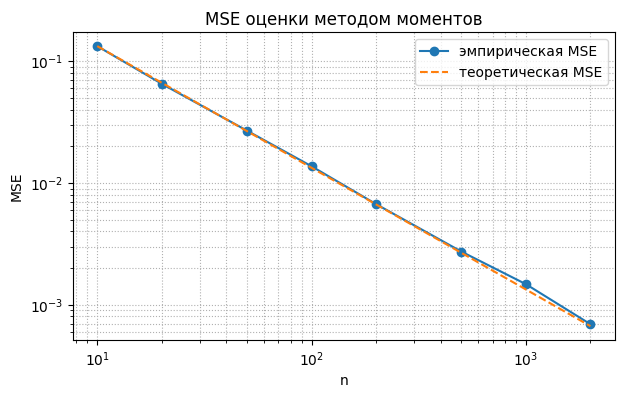

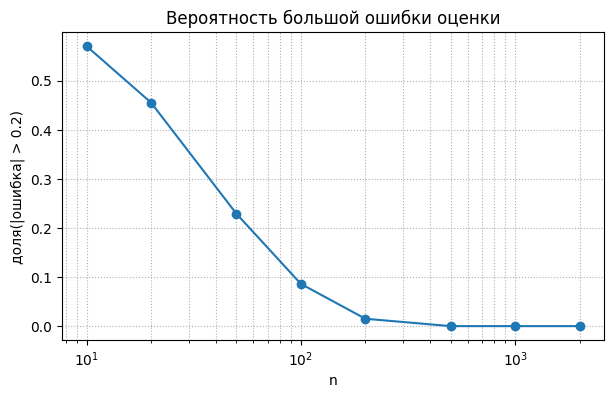

In [14]:
theta_true = 2.0
k = 3
n_values = np.array([10, 20, 50, 100, 200, 500, 1000, 2000])
m = 1000
eps0 = 0.2

mean_errors = []
mse_values = []
prob_big_error = []
theoretical_mse = theta_true**2 / (k * n_values)

rng = np.random.default_rng()

for n in n_values:
    samples = rng.gamma(shape=k, scale=theta_true, size=(m, n))
    means = samples.mean(axis=1)
    theta_hat = means / k
    errors = theta_hat - theta_true
    mean_errors.append(errors.mean())
    mse_values.append((errors**2).mean())
    prob_big_error.append(np.mean(np.abs(errors) > eps0))

mean_errors = np.array(mean_errors)
mse_values = np.array(mse_values)
prob_big_error = np.array(prob_big_error)

print("Результаты эксперимента")
for n, me, mse, p in zip(n_values, mean_errors, mse_values, prob_big_error):
    print(f"n = {n:5d} | средняя ошибка = {me: .4f} | MSE = {mse: .4f} | доля(|ошибка| > {eps0}) = {p: .3f}")

plt.figure(figsize=(7, 4))
plt.plot(n_values, mse_values, marker="o", label="эмпирическая MSE")
plt.plot(n_values, theoretical_mse, linestyle="--", label="теоретическая MSE")
plt.xlabel("n")
plt.ylabel("MSE")
plt.title("MSE оценки методом моментов")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.grid(True, which="both", linestyle=":")

plt.figure(figsize=(7, 4))
plt.plot(n_values, prob_big_error, marker="o")
plt.xlabel("n")
plt.ylabel(f"доля(|ошибка| > {eps0})")
plt.title("Вероятность большой ошибки оценки")
plt.xscale("log")
plt.grid(True, which="both", linestyle=":")

plt.show()


Ошибка для всех $n$ колеблется вокруг нуля. Это подтверждает то, что оценка несмещённая. К тому же видно, что на больших объемах выборки оценка становится достаточно точной. Результаты моделирования подтверждают аналитические выводы: оценка параметра $\theta$ методом моментов является несмещённой, состоятельной, асимптотически нормальной.

# Задание 3 (вариант 3)

Нужно предъявить доверительный интервал уровня $1 - \alpha$ для указанного параметра при данных предположениях (с математическими обоснованиями).

Сгенерировать две выборки объёма $25$ и посчитать доверительный интервал.
Повторить $1000$ раз. Посчитать, сколько раз $95\%$ доверительный интервал покрывает реальное значение параметра.

То же самое выполнить для объёма выборки $10000$.
Объяснить изменение результата.

Имеются две независимые выборки $X$ и $Y$ из распределений
$$
X \sim \mathcal{N}(\mu_1, \sigma_1^2), \qquad
Y \sim \mathcal{N}(\mu_2, \sigma_2^2),
$$
объёмов $n$ и $m$ соответственно.
Оцениваемая величина:
$$
\tau = \frac{\sigma_1^2}{\sigma_2^2}.
$$

Дано:
$\mu_1 = 0,\quad \mu_2 = 0,\quad \sigma_1^2 = 2,\quad \sigma_2^2 = 1.$

Для построения доверительного интервала надо использовать статистику
$$
\frac{n(m-1)\,\mathrm{Var}(X)}{m(n-1)\,\mathrm{Var}(Y)},
$$
где $\mathrm{Var}(\cdot)$ — выборочная смещённая дисперсия.

Необходимое распределение: распределение Фишера.


## Аналитическая часть

Пусть есть две независимые выборки
$$
X_1,\ldots,X_n \sim N(\mu_1,\sigma_1^2),\qquad
Y_1,\ldots,Y_m \sim N(\mu_2,\sigma_2^2),
$$
и нас интересует параметр
$$
\tau = \frac{\sigma_1^2}{\sigma_2^2}.
$$

В задаче даны
$$
\mu_1 = 0,\quad \mu_2 = 0,\quad \sigma_1^2 = 2,\quad \sigma_2^2 = 1,
$$
поэтому
$$
\tau_0 = \frac{\sigma_1^2}{\sigma_2^2} = 2.
$$

### 1. Переход к распределению Фишера

По условию используем смещённые выборочные дисперсии
$$
\operatorname{Var}(X)=\frac1n\sum_{i=1}^n (X_i-\overline X)^2,\qquad
\operatorname{Var}(Y)=\frac1m\sum_{j=1}^m (Y_j-\overline Y)^2.
$$

Также введём несмещённые выборочные дисперсии:
$$
S_X^2 = \frac{1}{n-1}\sum_{i=1}^n (X_i-\overline X)^2,\qquad
S_Y^2 = \frac{1}{m-1}\sum_{j=1}^m (Y_j-\overline Y)^2.
$$

Связь между смещённой и несмещённой дисперсией очевидна из определений:
$$
\operatorname{Var}(X)
=
\frac1n\sum_{i=1}^n (X_i-\overline X)^2,
$$
$$
S_X^2
=
\frac{1}{n-1}\sum_{i=1}^n (X_i-\overline X)^2
=
\frac{n}{n-1}\cdot \frac1n\sum_{i=1}^n (X_i-\overline X)^2
=
\frac{n}{n-1}\,\operatorname{Var}(X).
$$
Аналогично для выборки $Y$:
$$
S_Y^2 = \frac{m}{m-1}\,\operatorname{Var}(Y).
$$

Для нормального распределения известно, что
$$
\frac{(n-1)S_X^2}{\sigma_1^2} \sim \chi^2_{n-1},\qquad
\frac{(m-1)S_Y^2}{\sigma_2^2} \sim \chi^2_{m-1},
$$
и эти две случайные величины независимы.

Теперь подставим выражения для $S_X^2$ и $S_Y^2$ через $\operatorname{Var}(X)$ и $\operatorname{Var}(Y)$.

Сначала для $X$:
$$
\frac{(n-1)S_X^2}{\sigma_1^2}
=
\frac{(n-1)\cdot \dfrac{n}{n-1}\operatorname{Var}(X)}{\sigma_1^2}
=
\frac{n\,\operatorname{Var}(X)}{\sigma_1^2}
\sim \chi^2_{n-1}.
$$

Аналогично для $Y$:
$$
\frac{(m-1)S_Y^2}{\sigma_2^2}
=
\frac{(m-1)\cdot \dfrac{m}{m-1}\operatorname{Var}(Y)}{\sigma_2^2}
=
\frac{m\,\operatorname{Var}(Y)}{\sigma_2^2}
\sim \chi^2_{m-1},
$$
и эти две величины независимы.

Теперь рассмотрим отношение этих двух хи-квадрат с соответствующими степенями свободы:
$$
\frac{\dfrac{n\,\operatorname{Var}(X)}{\sigma_1^2}}
     {\dfrac{m\,\operatorname{Var}(Y)}{\sigma_2^2}}
\sim F_{n-1,m-1}.
$$

Отношение двух независимых хи-квадрат, делённых на степени свободы, имеет распределение Фишера.

Упростим дробь в левой части:
$$
\frac{\dfrac{n\,\operatorname{Var}(X)}{\sigma_1^2}}
     {\dfrac{m\,\operatorname{Var}(Y)}{\sigma_2^2}}
=
\frac{n\,\operatorname{Var}(X)}{\sigma_1^2}\cdot
\frac{\sigma_2^2}{m\,\operatorname{Var}(Y)}
=
\frac{n\,\operatorname{Var}(X)}{m\,\operatorname{Var}(Y)}\cdot
\frac{\sigma_2^2}{\sigma_1^2}.
$$

Помним, что
$$
\tau = \frac{\sigma_1^2}{\sigma_2^2},
\qquad
\frac{\sigma_2^2}{\sigma_1^2} = \frac{1}{\tau}.
$$

Подставляем:
$$
\frac{n\,\operatorname{Var}(X)}{m\,\operatorname{Var}(Y)}\cdot
\frac{1}{\tau}
\sim F_{n-1,m-1}.
$$

Теперь хотим выразить это через статистику, заданную в условии:
$$
T = \frac{n(m-1)\operatorname{Var}(X)}{m(n-1)\operatorname{Var}(Y)}.
$$

Распишем $T$:
$$
T
=
\frac{n(m-1)\operatorname{Var}(X)}{m(n-1)\operatorname{Var}(Y)}
=
\frac{m-1}{n-1}\cdot\frac{n\,\operatorname{Var}(X)}{m\,\operatorname{Var}(Y)}.
$$

Отсюда
$$
\frac{n\,\operatorname{Var}(X)}{m\,\operatorname{Var}(Y)}
=
\frac{n-1}{m-1}\,T.
$$

Подставляем это выражение в формулу с распределением Фишера:
$$
\frac{n\,\operatorname{Var}(X)}{m\,\operatorname{Var}(Y)}\cdot\frac{1}{\tau}
=
\frac{n-1}{m-1}\,T\cdot\frac{1}{\tau}
\sim F_{n-1,m-1}.
$$

Запишем чуть компактнее:
$$
\frac{n-1}{m-1}\,\frac{T}{\tau}
\sim F_{n-1,m-1}.
$$

Это и есть нужная связь между $\tau$ и статистикой $T$.


### 2. Доверительный интервал для $\tau$

Пусть $F_{\alpha/2}$ и $F_{1-\alpha/2}$ — квантили распределения Фишера $F_{n-1,m-1}$, то есть
$$
\mathbb P\bigl(F_{\alpha/2} \le Z \le F_{1-\alpha/2}\bigr) = 1-\alpha,
\qquad
Z\sim F_{n-1,m-1}.
$$

Статистика
$$
\frac{n-1}{m-1}\,\frac{T}{\tau}
$$
имеет распределение $F_{n-1,m-1}$, значит, вместо $Z$ можно подставить её:

$$
\mathbb P\left(
F_{\alpha/2} \le
\frac{n-1}{m-1}\,\frac{T}{\tau}
\le F_{1-\alpha/2}
\right) = 1-\alpha.
$$

Теперь решим это двойное неравенство относительно $\tau$.

Обозначим для краткости
$$
C = \frac{n-1}{m-1}\,T,
$$
тогда неравенство переписывается как
$$
F_{\alpha/2}
\le
\frac{C}{\tau}
\le
F_{1-\alpha/2}.
$$

1) Левая часть:
$$
F_{\alpha/2} \le \frac{C}{\tau}.
$$
Домножаем на $\tau>0$:
$$
F_{\alpha/2}\,\tau \le C.
$$
Теперь делим на $F_{\alpha/2}>0$:
$$
\tau \le \frac{C}{F_{\alpha/2}}.
$$

2) Правая часть:
$$
\frac{C}{\tau} \le F_{1-\alpha/2}.
$$
Домножаем на $\tau>0$:
$$
C \le F_{1-\alpha/2}\,\tau.
$$
Делим на $F_{1-\alpha/2}>0$:
$$
\frac{C}{F_{1-\alpha/2}} \le \tau.
$$

Объединяем оба результата:
$$
\frac{C}{F_{1-\alpha/2}}
\le
\tau
\le
\frac{C}{F_{\alpha/2}}.
$$

Возвращаем $C = \dfrac{n-1}{m-1}T$:
$$
\frac{\dfrac{n-1}{m-1}T}{F_{1-\alpha/2}}
\le
\tau
\le
\frac{\dfrac{n-1}{m-1}T}{F_{\alpha/2}}.
$$

Сократим запись:
$$
\tau_L = \frac{n-1}{m-1}\,\frac{T}{F_{1-\alpha/2; n-1,m-1}},\qquad
\tau_U = \frac{n-1}{m-1}\,\frac{T}{F_{\alpha/2; n-1,m-1}}.
$$

Итак, доверительный интервал уровня $1-\alpha$ для $\tau$:
$$
\left[
\tau_L,\ \tau_U
\right]
=
\left[
\frac{n-1}{m-1}\,\frac{T}{F_{1-\alpha/2; n-1,m-1}},\
\frac{n-1}{m-1}\,\frac{T}{F_{\alpha/2; n-1,m-1}}
\right],
$$
где
$$
T = \frac{n(m-1)\operatorname{Var}(X)}{m(n-1)\operatorname{Var}(Y)}.
$$

Для уровня $1-\alpha = 0.95$ берём $\alpha = 0.05$.


## Экспериментальная часть

In [15]:
alpha = 0.05
mu1 = 0.0
mu2 = 0.0
sigma1_sq = 2.0
sigma2_sq = 1.0
sigma1 = np.sqrt(sigma1_sq)
sigma2 = np.sqrt(sigma2_sq)
tau_true = sigma1_sq / sigma2_sq

def coverage(n, m, trials, rng):
    df1 = n - 1
    df2 = m - 1
    f_low = f.ppf(alpha / 2, df1, df2)
    f_high = f.ppf(1 - alpha / 2, df1, df2)
    hits = 0
    for _ in range(trials):
        X = rng.normal(mu1, sigma1, size=n)
        Y = rng.normal(mu2, sigma2, size=m)
        varX = X.var(ddof=0)
        varY = Y.var(ddof=0)
        R = n * (m - 1) * varX / (m * (n - 1) * varY)
        tau_L = R / f_high
        tau_U = R / f_low
        if tau_L <= tau_true <= tau_U:
            hits += 1
    return hits / trials

rng = np.random.default_rng()

cov_25 = coverage(25, 25, 1000, rng)
cov_10000 = coverage(10000, 10000, 1000, rng)

print("Доля покрытия для n = m = 25:", cov_25)
print("Доля покрытия для n = m = 10000:", cov_10000)

Доля покрытия для n = m = 25: 0.944
Доля покрытия для n = m = 10000: 0.954


Доверительный интервал на основе распределения Фишера был построен корректно.

# Задание 4 (вариант 2)

Построить асимптотический доверительный интервал уровня $1 - \alpha$ для указанного параметра и провести эксперимент по схеме, аналогичной первой задаче.

Распределение: распределение Лапласа с неизвестным параметром сдвига $\mu$ и единичным масштабирующим параметром.
Оцениваемый параметр: $\mu$.

Эксперимент проводится при значении параметра
$$
\mu = 2.
$$

Требуется:
1. Выписать асимптотический доверительный интервал уровня $1 - \alpha$ для параметра $\mu$.
2. Сгенерировать выборки объёмов, заданных в эксперименте.
3. Для каждой выборки построить доверительный интервал.
4. Повторить эксперимент требуемое число раз и оценить частоту покрытия истинного параметра.
5. Проанализировать результат и объяснить его поведение при увеличении размера выборки.


# Задание 5 (вариант 3)

Для каждой проблемы нужно провести два статистических теста.
Первый тест необходимо реализовать самостоятельно: вычислить и вывести значение статистики, критическое значение и p-value.
Второй тест можно выполнить с помощью готовой реализации.

Также требуется явно указать формализации $H_0$ и $H_1$ для выбранных тестов.
Уровень значимости выбирается самостоятельно.

В датасете приведены данные о результатах вступительных экзаменов.

1. Предположить, с каким вероятностным распределением согласуется суммарный балл за экзамены.
   С помощью статистического теста подтвердить или опровергнуть это предположение.
2. Проверить, верно ли, что распределения баллов по математике и чтению одинаковы.
